# Sprint 1 — Ground Truth Validation

Validates `data/test_history.db` loaded from RTPTorrent CSVs.

**Run from repo root** with the venv active:
```
.venv\Scripts\Activate.ps1
jupyter notebook notebooks/01_ground_truth_validation.ipynb
```

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root whether launched from repo root or notebooks/ directory.
_cwd = Path(os.getcwd())
REPO_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
assert (REPO_ROOT / "data").exists(), f"Cannot locate repo root from {_cwd}"

DB_PATH = REPO_ROOT / "data" / "test_history.db"
RTP_PATH = REPO_ROOT / "data" / "repos" / "rtp-torrent"
SELECTED_PROJECTS = [
    "deeplearning4j@deeplearning4j",
    "l0rdn1kk0n@wicket-bootstrap",
    "neuland@jade4j",
]

assert DB_PATH.exists(), f"DB not found: {DB_PATH}"
con = sqlite3.connect(DB_PATH)
print(f"REPO_ROOT : {REPO_ROOT}")
print(f"Connected : {DB_PATH}")

REPO_ROOT : D:\FSB\FSB-Capstone
Connected : D:\FSB\FSB-Capstone\data\test_history.db


## 1. Overall Row Counts

In [2]:
total_runs = pd.read_sql("SELECT COUNT(*) as total FROM test_runs", con).iloc[0, 0]
total_changes = pd.read_sql("SELECT COUNT(*) as total FROM file_changes", con).iloc[0, 0]

print(f"test_runs total rows : {total_runs:,}")
print(f"file_changes total rows: {total_changes:,}")

assert total_runs >= 10_000, f"FAIL: test_runs has {total_runs} rows, need >= 10,000"
print("\nPASS: test_runs >= 10,000")

test_runs total rows : 22,539,830
file_changes total rows: 414,461

PASS: test_runs >= 10,000


## 2. Per-Project Row Counts (all repos)

In [3]:
per_project = pd.read_sql(
    """
    SELECT repo,
           COUNT(*) AS test_run_rows,
           COUNT(DISTINCT job_id) AS distinct_jobs,
           COUNT(DISTINCT test_id) AS distinct_tests
    FROM test_runs
    GROUP BY repo
    ORDER BY test_run_rows DESC
    """,
    con,
)
per_project["selected"] = per_project["repo"].isin(SELECTED_PROJECTS)
display(per_project)

,repo,test_run_rows,distinct_jobs,distinct_tests,selected
0,SonarSource@sonarqube,17115609,53307,3365,False
1,apache@sling,1533296,8552,673,False
2,Graylog2@graylog2-server,905070,10622,324,False
3,facebook@buck,781126,1148,894,False
4,jcabi@jcabi-github,552160,3241,201,False
5,square@okhttp,412644,9772,292,False
6,CloudifySource@cloudify,285828,5206,118,False
7,DSpace@DSpace,207640,3338,106,False
8,doanduyhai@Achilles,169958,997,636,False
9,jsprit@jsprit,94253,1089,110,False


## 3. Per-Project Failure Rate and Null commit_sha Rate

In [4]:
quality = pd.read_sql(
    """
    SELECT
        repo,
        COUNT(*) AS total,
        SUM(CASE WHEN outcome = 'FAIL'    THEN 1 ELSE 0 END) AS fails,
        SUM(CASE WHEN outcome = 'PASS'    THEN 1 ELSE 0 END) AS passes,
        SUM(CASE WHEN outcome = 'SKIPPED' THEN 1 ELSE 0 END) AS skipped,
        SUM(CASE WHEN commit_sha IS NULL  THEN 1 ELSE 0 END) AS null_sha
    FROM test_runs
    GROUP BY repo
    ORDER BY repo
    """,
    con,
)
quality["failure_rate"] = quality["fails"] / quality["total"]
quality["null_sha_rate"] = quality["null_sha"] / quality["total"]
quality["selected"] = quality["repo"].isin(SELECTED_PROJECTS)

# Flag projects with high null_sha rate
high_null = quality[quality["null_sha_rate"] > 0.40]
if not high_null.empty:
    print("WARNING: repos with null commit_sha rate > 40%:")
    print(high_null[["repo", "null_sha_rate"]].to_string(index=False))

low_fail = quality[(quality["selected"]) & (quality["failure_rate"] < 0.02)]
if not low_fail.empty:
    print("\nWARNING: selected repos with failure rate < 2% (candidates for replacement):")
    print(low_fail[["repo", "failure_rate"]].to_string(index=False))

display(quality[["repo", "total", "fails", "passes", "skipped", "null_sha",
                 "failure_rate", "null_sha_rate", "selected"]])

                 repo  null_sha_rate
        DSpace@DSpace       0.418508
SonarSource@sonarqube       0.608167
         apache@sling       0.825336
        square@okhttp       0.428616


,repo,total,fails,passes,skipped,null_sha,failure_rate,null_sha_rate,selected
0,CloudifySource@cloudify,285828,701,268938,16189,11481,0.002453,0.040168,False
1,DSpace@DSpace,207640,3706,203934,0,86899,0.017848,0.418508,False
2,Graylog2@graylog2-server,905070,357,894375,10338,302877,0.000394,0.334645,False
3,SonarSource@sonarqube,17115609,10769,17079739,25101,10409150,0.000629,0.608167,False
4,adamfisk@LittleProxy,15772,187,14563,1022,4798,0.011856,0.304210,False
5,apache@sling,1533296,7654,1514564,11078,1265484,0.004992,0.825336,False
6,brettwooldridge@HikariCP,23693,293,23400,0,1498,0.012367,0.063225,False
7,deeplearning4j@deeplearning4j,15509,932,13769,808,884,0.060094,0.056999,True
8,doanduyhai@Achilles,169958,392,169512,54,36378,0.002306,0.214041,False
9,dynjs@dynjs,74741,510,72196,2035,6206,0.006824,0.083033,False


## 4. Outcome Distribution (selected projects)

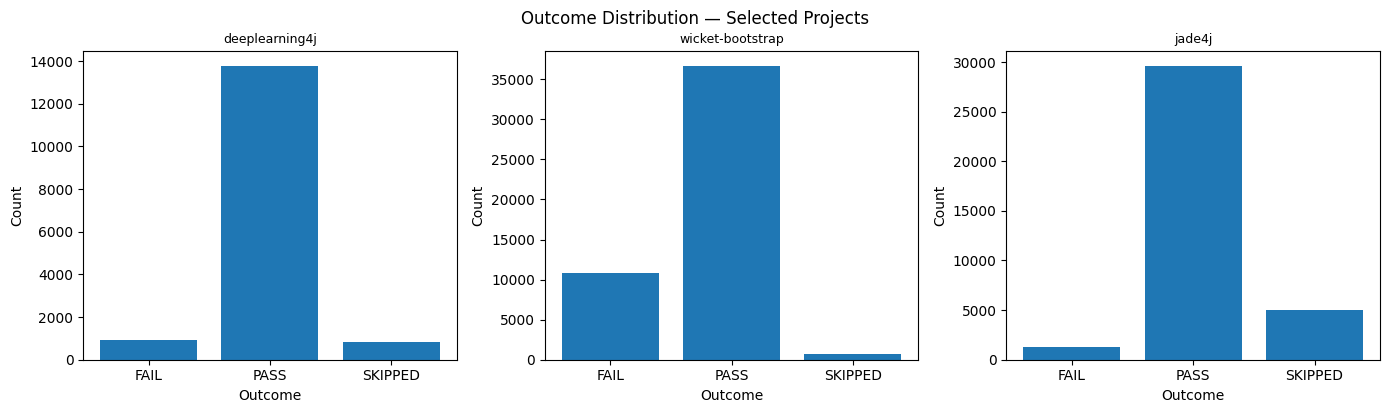

,repo,outcome,cnt
0,deeplearning4j@deeplearning4j,FAIL,932
1,deeplearning4j@deeplearning4j,PASS,13769
2,deeplearning4j@deeplearning4j,SKIPPED,808
3,l0rdn1kk0n@wicket-bootstrap,FAIL,10860
4,l0rdn1kk0n@wicket-bootstrap,PASS,36648
5,l0rdn1kk0n@wicket-bootstrap,SKIPPED,720
6,neuland@jade4j,FAIL,1323
7,neuland@jade4j,PASS,29599
8,neuland@jade4j,SKIPPED,4965


In [5]:
placeholders = ",".join(["?"] * len(SELECTED_PROJECTS))
outcome_dist = pd.read_sql(
    f"""
    SELECT repo, outcome, COUNT(*) AS cnt
    FROM test_runs
    WHERE repo IN ({placeholders})
    GROUP BY repo, outcome
    ORDER BY repo, outcome
    """,
    con,
    params=SELECTED_PROJECTS,
)

fig, axes = plt.subplots(1, len(SELECTED_PROJECTS), figsize=(14, 4))
for ax, project in zip(axes, SELECTED_PROJECTS):
    data = outcome_dist[outcome_dist["repo"] == project]
    ax.bar(data["outcome"], data["cnt"])
    ax.set_title(project.split("@")[1], fontsize=9)
    ax.set_xlabel("Outcome")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.suptitle("Outcome Distribution — Selected Projects", y=1.02)
plt.show()

display(outcome_dist)

## 5. Top 10 Most Frequently Failing Tests (per selected project)

In [6]:
for project in SELECTED_PROJECTS:
    top10 = pd.read_sql(
        """
        SELECT test_id, COUNT(*) AS fail_count
        FROM test_runs
        WHERE repo = ? AND outcome = 'FAIL'
        GROUP BY test_id
        ORDER BY fail_count DESC
        LIMIT 10
        """,
        con,
        params=[project],
    )
    print(f"\n=== {project} ===")
    display(top10)


=== deeplearning4j@deeplearning4j ===


,test_id,fail_count
0,org.deeplearning4j.nn.graph.TestCompGraphMulti,84
1,org.deeplearning4j.rbm.ConvRBMTest,82
2,org.deeplearning4j.rbm.RBMTest,72
3,org.deeplearning4j.sda.SdaTest,60
4,org.deeplearning4j.eval.EvalTest,56
5,org.deeplearning4j.convolution.ConvolutionTest,52
6,org.deeplearning4j.autoencoder.DeepAutoEncoder...,44
7,org.deeplearning4j.datasets.DataSetTest,35
8,org.deeplearning4j.dbn.DBNTest,29
9,org.deeplearning4j.models.layers.ConvolutionDo...,23



=== l0rdn1kk0n@wicket-bootstrap ===


,test_id,fail_count
0,de.agilecoders.wicket.core.markup.html.themes....,375
1,de.agilecoders.wicket.core.markup.html.bootstr...,375
2,de.agilecoders.wicket.core.markup.html.bootstr...,375
3,de.agilecoders.wicket.core.util.AttributesTest,374
4,de.agilecoders.wicket.core.settings.SingleThem...,374
5,de.agilecoders.wicket.core.markup.html.themes....,374
6,de.agilecoders.wicket.core.markup.html.bootstr...,374
7,de.agilecoders.wicket.core.markup.html.bootstr...,374
8,de.agilecoders.wicket.core.markup.html.bootstr...,374
9,de.agilecoders.wicket.core.markup.html.bootstr...,374



=== neuland@jade4j ===


,test_id,fail_count
0,de.neuland.jade4j.exceptions.JadeExceptionTest,68
1,de.neuland.jade4j.compiler.OriginalJade2015051...,65
2,de.neuland.jade4j.compiler.CompilerTest,62
3,de.neuland.jade4j.compiler.OriginalJadeTest,61
4,de.neuland.jade4j.parser.LargeBodyTextWithoutP...,57
5,de.neuland.jade4j.parser.IncludeParserTest,57
6,de.neuland.jade4j.lexer.token.TextTest,57
7,de.neuland.jade4j.lexer.token.TagTest,57
8,de.neuland.jade4j.lexer.token.PipelessTextTest,57
9,de.neuland.jade4j.lexer.token.OutdentTest,57


## 6. Duration Distribution (selected projects)


deeplearning4j@deeplearning4j duration_ms (n=13,804):
  min     : 1.0 ms
  median  : 737.0 ms
  p95     : 89,371.3 ms
  max     : 2,586,712.0 ms
  mean    : 35,645.5 ms


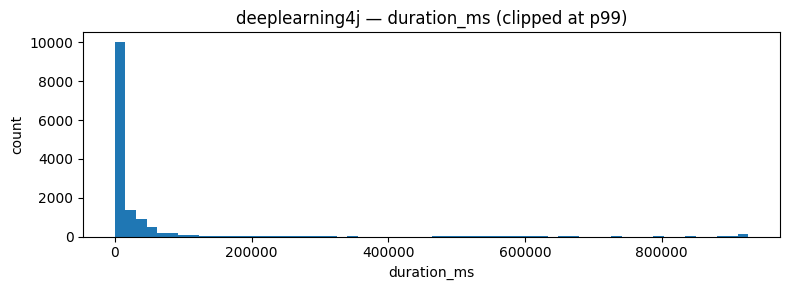


l0rdn1kk0n@wicket-bootstrap duration_ms (n=47,678):
  min     : 1.0 ms
  median  : 53.0 ms
  p95     : 695.0 ms
  max     : 12,389.0 ms
  mean    : 164.1 ms


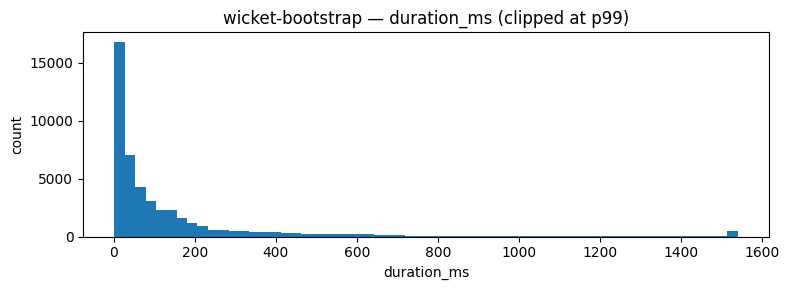


neuland@jade4j duration_ms (n=24,512):
  min     : 1.0 ms
  median  : 4.0 ms
  p95     : 639.0 ms
  max     : 572,163.0 ms
  mean    : 167.2 ms


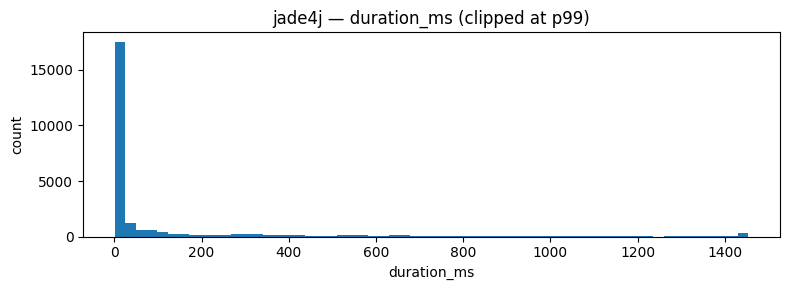

In [7]:
for project in SELECTED_PROJECTS:
    dur = pd.read_sql(
        """
        SELECT duration_ms
        FROM test_runs
        WHERE repo = ? AND duration_ms IS NOT NULL AND duration_ms > 0
        """,
        con,
        params=[project],
    )["duration_ms"]

    stats = {
        "min": dur.min(),
        "median": dur.median(),
        "p95": dur.quantile(0.95),
        "max": dur.max(),
        "mean": dur.mean(),
    }
    print(f"\n{project} duration_ms (n={len(dur):,}):")
    for k, v in stats.items():
        print(f"  {k:8s}: {v:,.1f} ms")

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(dur.clip(upper=dur.quantile(0.99)), bins=60, edgecolor="none")
    ax.set_title(f"{project.split('@')[1]} — duration_ms (clipped at p99)")
    ax.set_xlabel("duration_ms")
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()

## 7. file_changes Rows per Selected Project

In [8]:
placeholders = ",".join(["?"] * len(SELECTED_PROJECTS))
fc_counts = pd.read_sql(
    f"""
    SELECT repo,
           COUNT(*) AS file_change_rows,
           COUNT(DISTINCT commit_sha) AS distinct_commits
    FROM file_changes
    WHERE repo IN ({placeholders})
    GROUP BY repo
    """,
    con,
    params=SELECTED_PROJECTS,
)
display(fc_counts)

,repo,file_change_rows,distinct_commits
0,deeplearning4j@deeplearning4j,61402,2607
1,l0rdn1kk0n@wicket-bootstrap,10248,1294
2,neuland@jade4j,3135,374


## 8. Cross-Check vs Offenders CSV

For each selected project, verify that jobs flagged in `<project>-offenders.csv`
have matching `outcome=FAIL` rows in `test_runs`.

In [9]:
import csv

for project in SELECTED_PROJECTS:
    offenders_path = RTP_PATH / project / f"{project}-offenders.csv"
    if not offenders_path.exists():
        print(f"{project}: offenders CSV not found — skipping cross-check")
        continue

    offender_jobs: set[str] = set()
    with offenders_path.open("r", newline="", encoding="utf-8-sig") as fh:
        reader = csv.DictReader(fh)
        for row in reader:
            jid = row.get("travisJobId", row.get("job_id", "")).strip()
            if jid:
                offender_jobs.add(jid)

    if not offender_jobs:
        print(f"{project}: no offender job IDs parsed")
        continue

    placeholders_jobs = ",".join(["?"] * len(offender_jobs))
    matched = pd.read_sql(
        f"""
        SELECT COUNT(DISTINCT job_id) AS matched_jobs
        FROM test_runs
        WHERE repo = ? AND outcome = 'FAIL' AND job_id IN ({placeholders_jobs})
        """,
        con,
        params=[project] + list(offender_jobs),
    ).iloc[0, 0]

    pct = matched / len(offender_jobs) * 100 if offender_jobs else 0
    print(f"{project}: {matched}/{len(offender_jobs)} offender jobs have FAIL rows ({pct:.1f}%)")
    if pct < 50:
        print(f"  WARNING: low cross-check match rate for {project}")

deeplearning4j@deeplearning4j: no offender job IDs parsed
l0rdn1kk0n@wicket-bootstrap: no offender job IDs parsed
neuland@jade4j: no offender job IDs parsed


## 9. Summary Assertions

In [10]:
selected_quality = quality[quality["repo"].isin(SELECTED_PROJECTS)].copy()

print("=== Sprint 1 Acceptance Checks ===")
print(f"Total test_runs: {total_runs:,} (need >= 10,000)")

for _, row in selected_quality.iterrows():
    repo = row["repo"]
    fr = row["failure_rate"]
    nr = row["null_sha_rate"]
    fail_ok = fr >= 0.02
    null_warn = nr > 0.40
    status = "OK" if fail_ok else "FAIL (failure_rate < 2%)"
    warn = " | WARNING: null_sha > 40%" if null_warn else ""
    print(f"  {repo}: failure_rate={fr:.2%}, null_sha={nr:.1%} [{status}{warn}]")

print("\nValidation complete.")
con.close()

=== Sprint 1 Acceptance Checks ===
Total test_runs: 22,539,830 (need >= 10,000)
  deeplearning4j@deeplearning4j: failure_rate=6.01%, null_sha=5.7% [OK]
  l0rdn1kk0n@wicket-bootstrap: failure_rate=22.52%, null_sha=19.3% [OK]
  neuland@jade4j: failure_rate=3.69%, null_sha=0.1% [OK]

Validation complete.
